In [1]:
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget
base_dir = Path(r"H:\FUBerlin\Measurements\Raman Xplora\CristianB")
target_dir = base_dir / "20260402_CNT_F005_6FBz@P2/785nm"

HFBz = target_dir / "260402_Hexafluorobenzene6FBz_785 nm_1200gr_x10_10%_2_120_50_100.txt"
pP2Ref = target_dir / "260402_P2ReferencePowd_785 nm_1200gr_x10_10%_2_120_50_100.txt"
pF005AP = target_dir / "260402_F005_6FBZ@P2LyopPowder_785 nm_1200gr_x10_10%_2_120_50_100.txt"
pF005LP = target_dir / "260402_F005_6FBZ@P2Pellet_785 nm_1200gr_x10_10%_2_120_50_100.txt"
sP2Ref = target_dir / "260402_P2ReferenceSol_785 nm_1200gr_x10_10%_2_120_50_100.txt"
sF005AP = target_dir / "260402_F005_6FBZ@P2Sol_785 nm_1200gr_x10_10%_2_120_50_100.txt"


df_pP2Ref = pd.read_csv(pP2Ref, sep="\t", comment="#", header=None, encoding="latin1")
df_pF005AP = pd.read_csv(pF005AP, sep="\t", comment="#", header=None, encoding="latin1")
df_pF005LP = pd.read_csv(pF005LP, sep="\t", comment="#", header=None, encoding="latin1")
df_sP2Ref = pd.read_csv(sP2Ref, sep="\t", comment="#", header=None, encoding="latin1")
df_sF005AP = pd.read_csv(sF005AP, sep="\t", comment="#", header=None, encoding="latin1")
df_HFBz = pd.read_csv(HFBz, sep="\t", comment="#", header=None, encoding="latin1")

In [2]:
DFs = [df_HFBz,
       df_pP2Ref,
       df_pF005AP,
       df_pF005LP,
       df_sP2Ref,
       df_sF005AP
       ]

DF_labels = [
       "6FBz",
       "Arc SWCNT powd",
       "6FBz@ArcSWCNT powd",
       "6FBz@ArcSWCNT powd lyop.",
       "Arc SWCNT sol",
       "6FBz@ArcSWCNT powd"
]


In [3]:
#CUSTOMIZATION

poster_style = {
    "figsize": (4, 4),          # poster-friendly
    "dpi": 300,                 # high resolution
    "font_size": 12,
    "title_size": 14,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1,
    "font_family": "Calibri",
    
    # Optional: define your own colors
    "colors": None  # e.g. ["red", "blue", "green"]
}

In [4]:
def plot_raman(data, labels=None, style=poster_style, xlim=None, ylim = None,offset=0):
    
    plt.figure(figsize=style["figsize"], dpi=style["dpi"])
    
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"]
    })
    
    colors = style["colors"]
    
    for i, df in enumerate(data):
        label = labels[i] if labels and i < len(labels) else f"Sample {i+1}"
        
        y = df.iloc[:, 1] + i * offset
        
        plt.plot(
            df.iloc[:, 0],
            y,
            label=label,
            linewidth=style["line_width"],
            color=colors[i] if colors else None
        )
        plt.scatter(df.iloc[:, 0], y, s=0.2)
    
    plt.xlabel("Raman shift (cm-1)", fontsize=style["label_size"])
    plt.ylabel("Intensity (a.u.)", fontsize=style["label_size"])
    plt.title("Raman Spectrum (785nm)", fontsize=style["title_size"])
    
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.legend(fontsize=style["legend_size"])
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

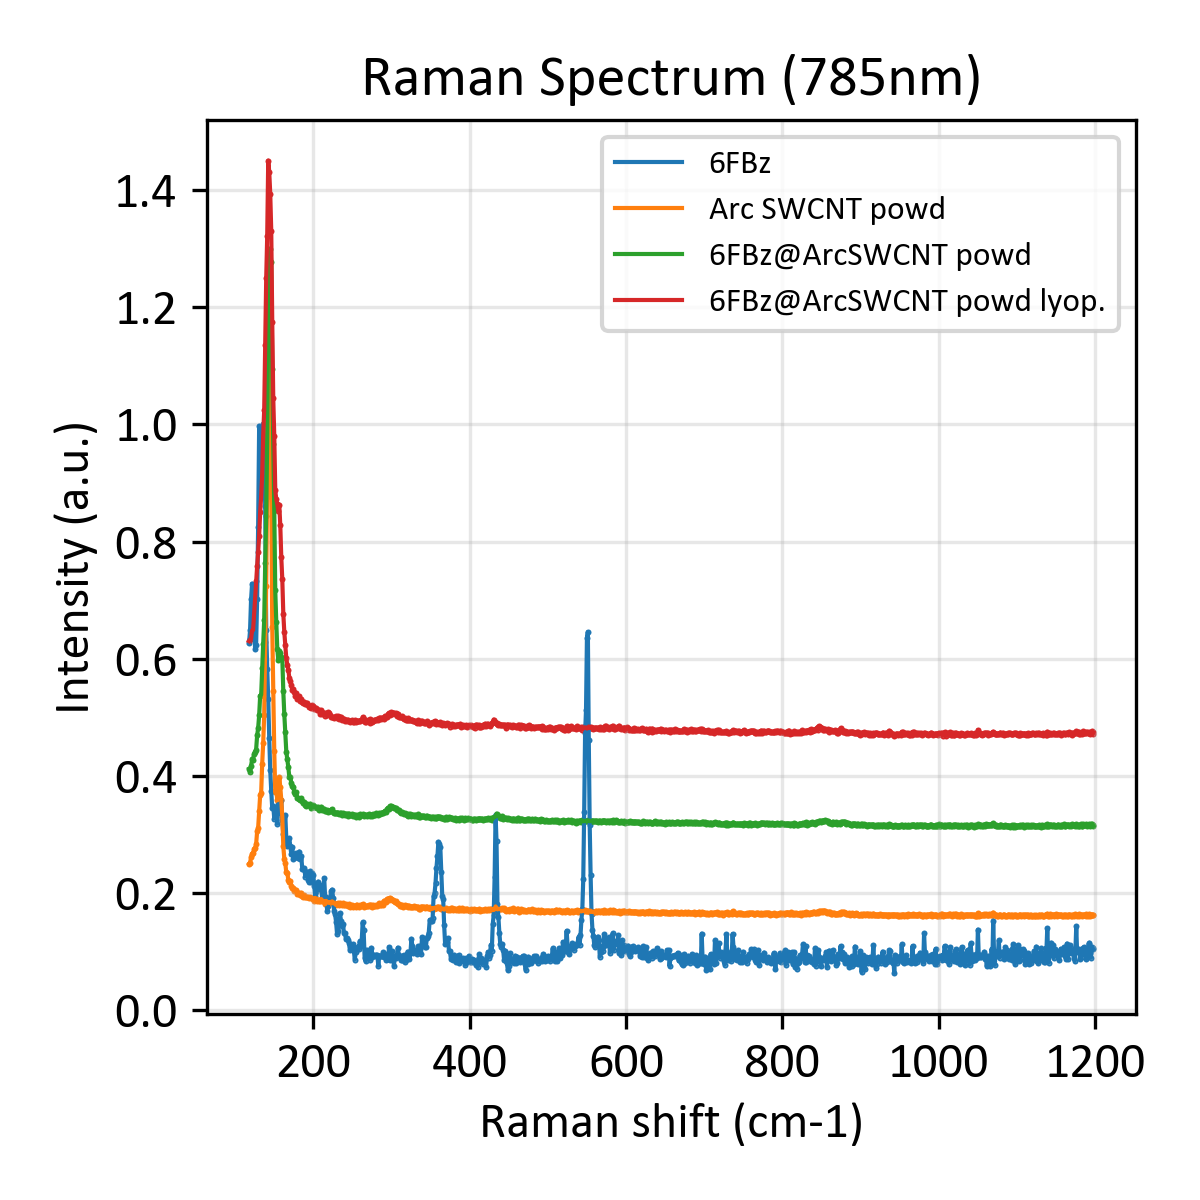

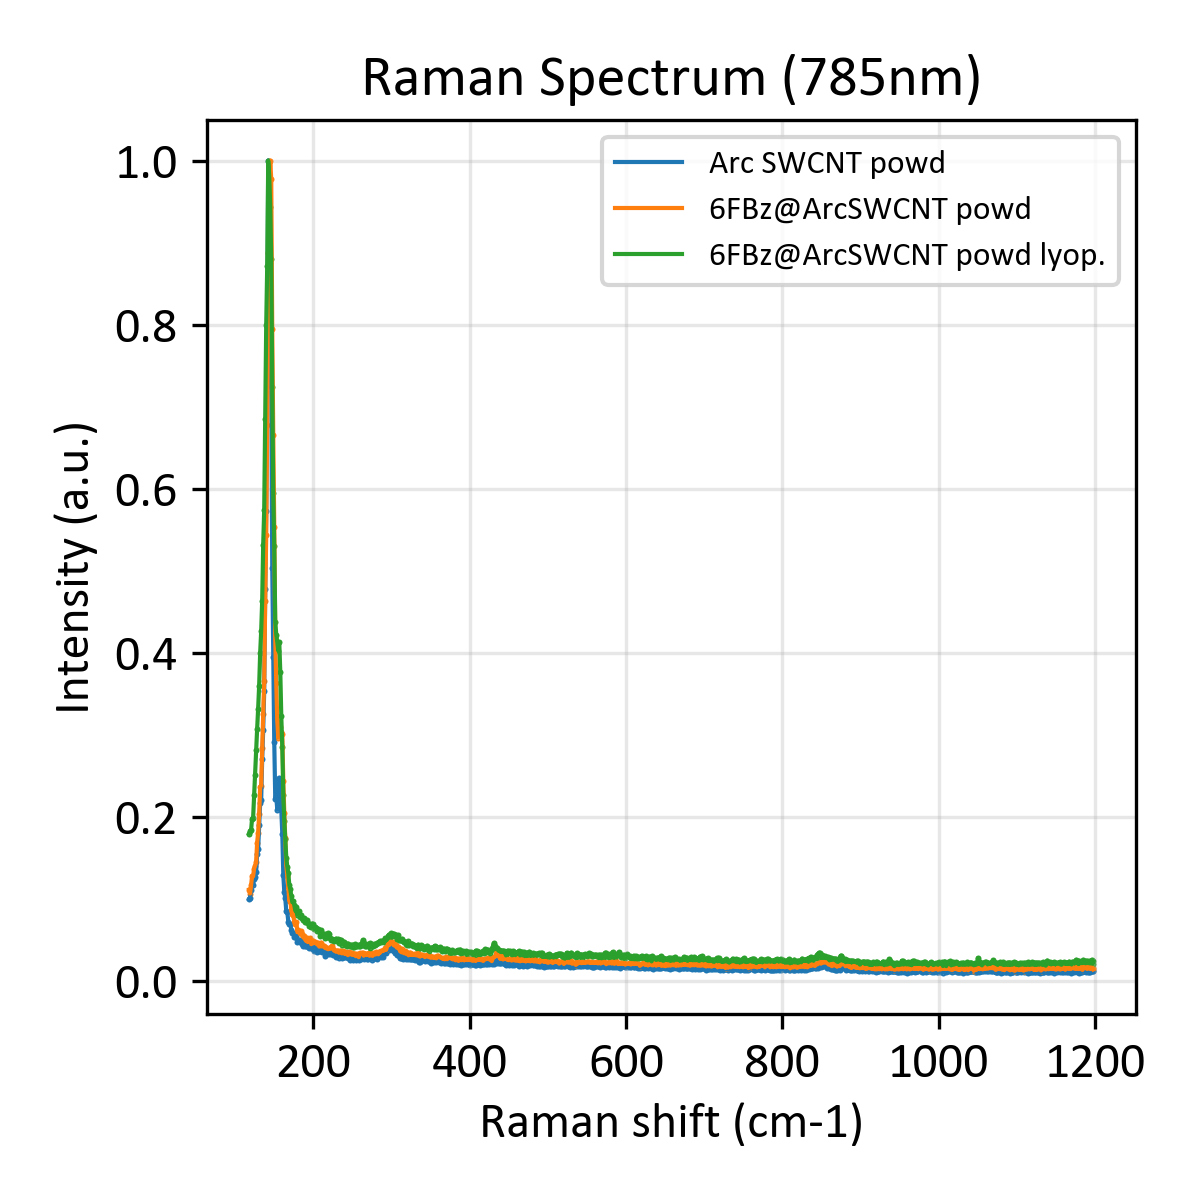

In [5]:
DFs = [
       df_HFBz,
       df_pP2Ref,
       df_pF005AP,
       df_pF005LP,
       #df_sP2Ref,
       #df_sF005AP
       ]

DF_labels = [
       "6FBz",
       "Arc SWCNT powd",
       "6FBz@ArcSWCNT powd",
       "6FBz@ArcSWCNT powd lyop.",
       #"Arc SWCNT sol",
       #"6FBz@ArcSWCNT sol"
       ]



DFs_norm = []

for df in DFs:
    df_norm = df.copy()
    df_norm.iloc[:, 1] = df_norm.iloc[:, 1] / df_norm.iloc[:, 1].max()
    DFs_norm.append(df_norm)


DFs = DFs_norm


plot_raman(DFs, DF_labels, offset=0.15)
#plot_raman(DFs, DF_labels, xlim=(120, 200), ylim=(0, 1.2), offset=0.0)
plot_raman(DFs[1:], DF_labels[1:], offset=0.0)

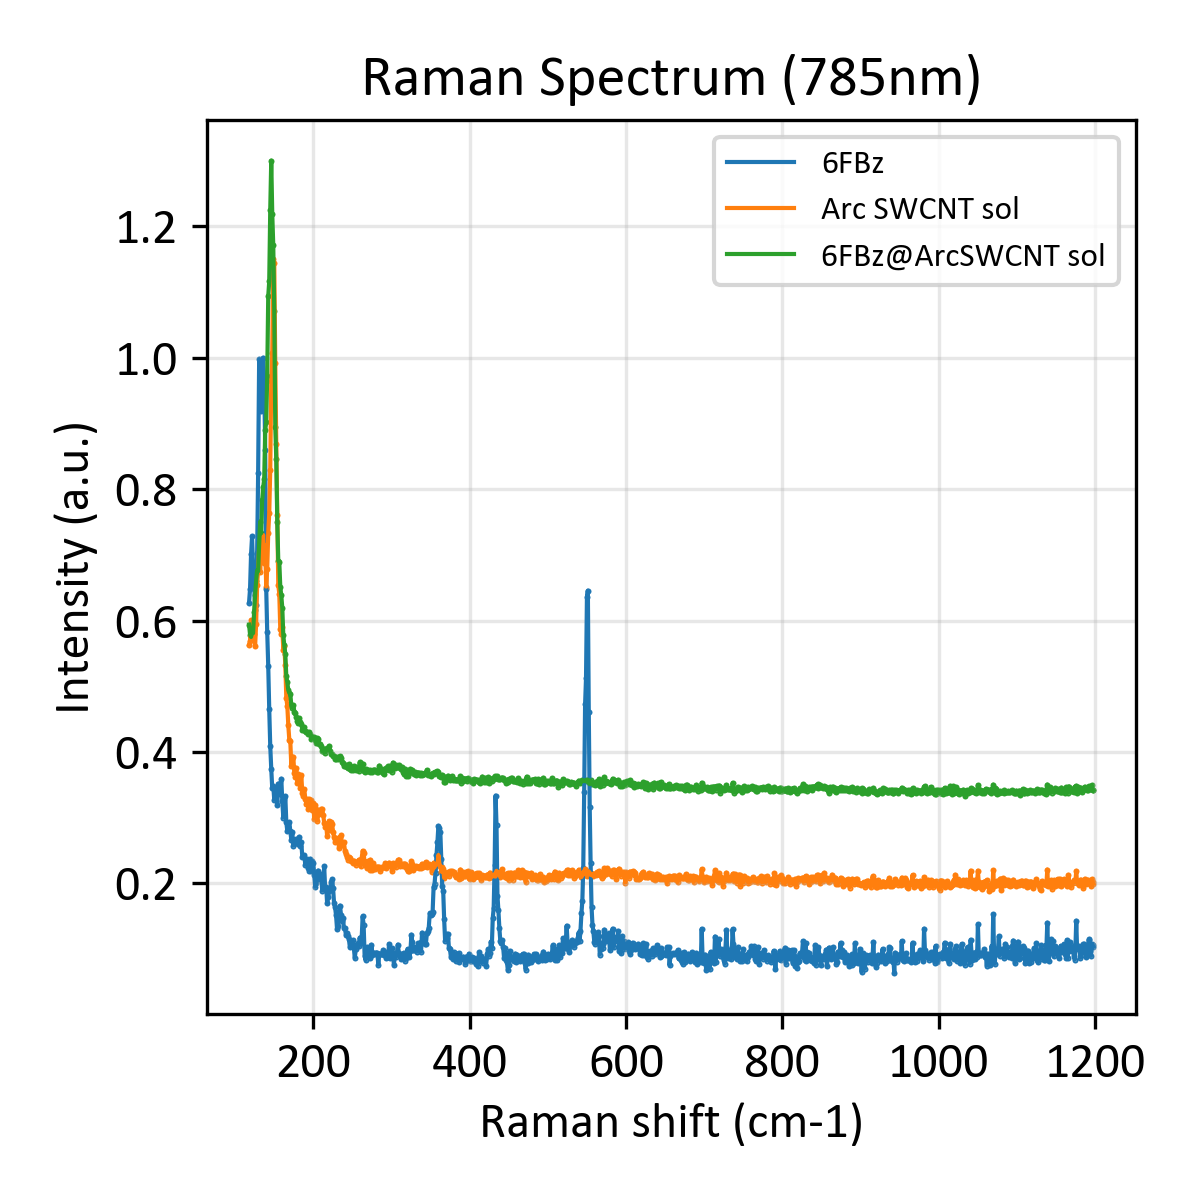

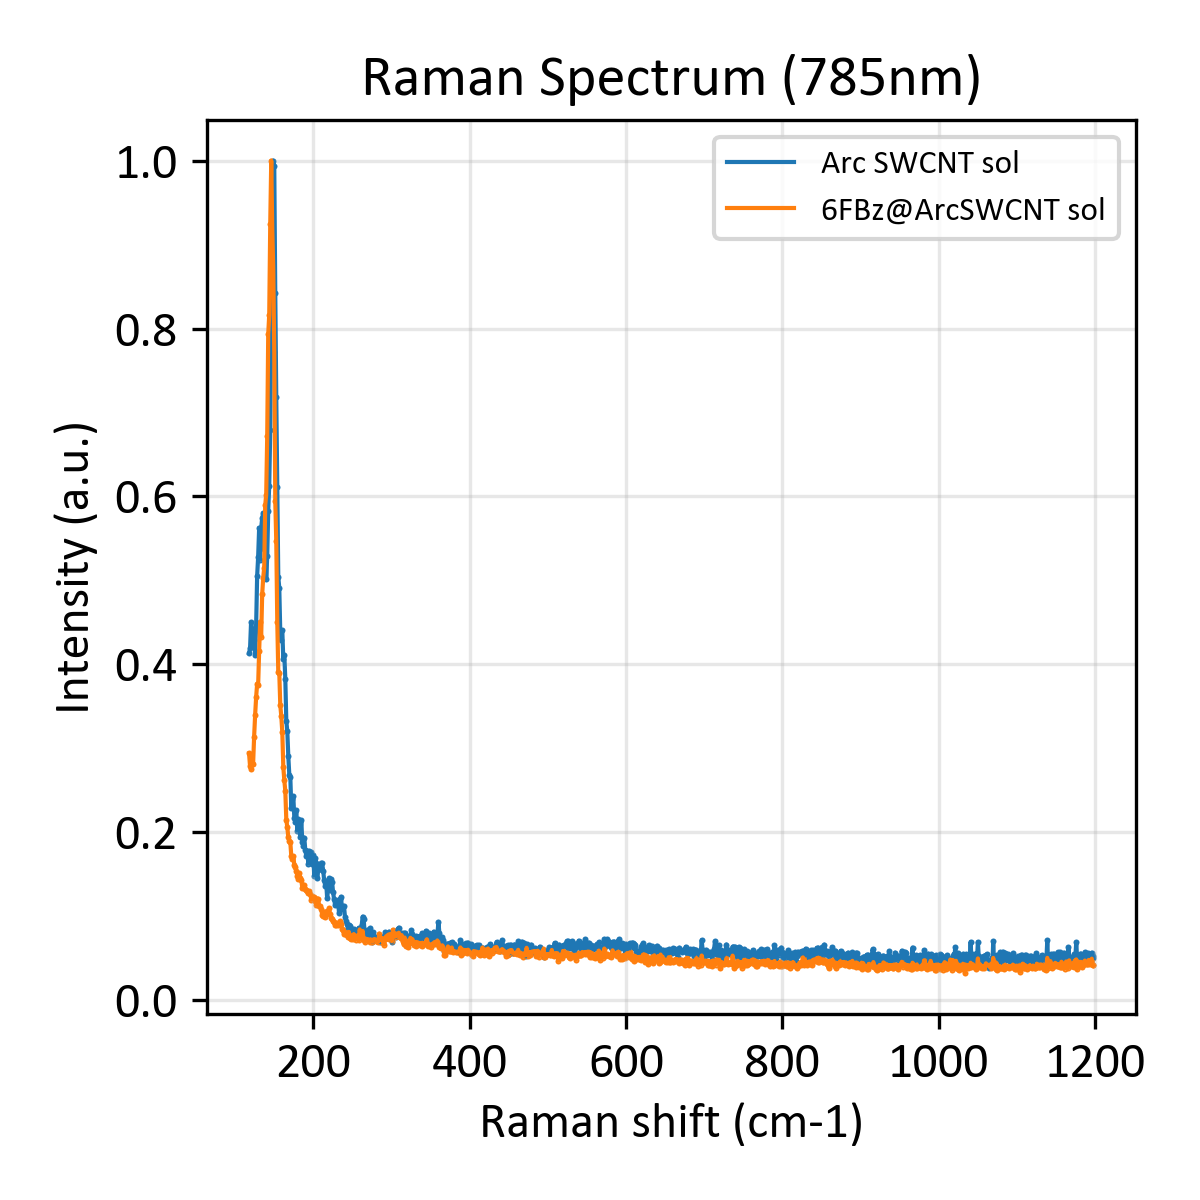

In [6]:
DFs = [
       df_HFBz,
       #df_pP2Ref,
       #df_pF005AP,
       #df_pF005LP,
       df_sP2Ref,
       df_sF005AP
       ]

DF_labels = [
       "6FBz",
       #"Arc SWCNT powd",
       #"6FBz@ArcSWCNT powd",
       #"6FBz@ArcSWCNT powd lyop.",
       "Arc SWCNT sol",
       "6FBz@ArcSWCNT sol"
       ]



DFs_norm = []

for df in DFs:
    df_norm = df.copy()
    df_norm.iloc[:, 1] = df_norm.iloc[:, 1] / df_norm.iloc[:, 1].max()
    DFs_norm.append(df_norm)


DFs = DFs_norm


plot_raman(DFs, DF_labels, offset=0.15)
#plot_raman(DFs, DF_labels, xlim=(120, 200), ylim=(0, 1.2), offset=0.0)
plot_raman(DFs[1:], DF_labels[1:], offset=0.0)